## Medical Insurance Cost Prediction using Decision Tree Regression

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [2]:
df = pd.read_csv("insurance.csv")

## Explore Dataset

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Data Preprocessing

In [6]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Defining Features (X) and Target (y)

In [7]:
X = df.drop("charges", axis=1)
y = df["charges"]

## Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

In [35]:
model = DecisionTreeRegressor(
    random_state=42,
    max_depth=4
)

model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Prediction

In [36]:
y_pred = model.predict(X_test)

## Model Evaluation

In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae}")
print(f"Mean Squared Error : {mse}")
print(f"R² Score : {r2}")

Mean Absolute Error : 2697.76543053848
Mean Squared Error : 21093484.004597444
R² Score : 0.8641310379678357


## Actual vs Predicted Charges

In [38]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
764,9095.06825,10662.682863
887,5272.17580,5703.338752
890,29330.98315,27503.008287
1293,9301.89355,10662.682863
259,33750.29180,35031.660932


## Feature Importance

In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,smoker_yes,0.703212
1,bmi,0.178707
0,age,0.114492
2,children,0.003589
3,sex_male,0.000000
5,region_northwest,0.000000
6,region_southeast,0.000000
7,region_southwest,0.000000


## Data Visualization - Scatter Plot

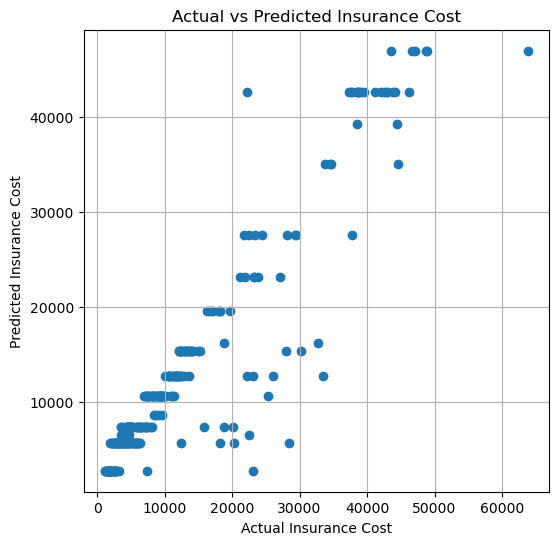

In [42]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Insurance Cost")
plt.ylabel("Predicted Insurance Cost")
plt.title("Actual vs Predicted Insurance Cost")

plt.grid(True)

plt.show()

## Conclusion

The Decision Tree Regression model was successfully used to predict medical insurance charges. 

It achieved an MAE of 2,697.77, MSE of 21,093,484.00, and an R² Score of 0.8641, indicating good predictive performance. 

Overall, the model captured the relationship between the input features and insurance charges effectively, making it suitable for this prediction task.